In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Activation, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

2024-02-03 02:25:27.298432: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-03 02:25:27.298587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-03 02:25:27.455839: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
digimon_dataset_path = '../input/digimon-images-dataset/digimon'
pokemon_dataset_path = '../input/pokemon-images-dataset/pokemon/pokemon'

In [3]:
def load_images_from_folder(folder, label, image_format):
    images = []
    labels = []
    for filename in os.listdir(folder):
        if filename.endswith(image_format):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).resize((120, 120))
            if image_format == '.png':
                img = img.convert('RGB')
            img = np.array(img)
            if img.shape == (120, 120, 3):
                images.append(img)
                labels.append(label)
    return images, labels

In [4]:
# Load image and label
digimon_images, digimon_labels = load_images_from_folder(digimon_dataset_path, 0, '.jpg')
pokemon_images, pokemon_labels = load_images_from_folder(pokemon_dataset_path, 1, '.png')

# Convert image to numpy array
digimon_images = np.array(digimon_images)
pokemon_images = np.array(pokemon_images)
digimon_labels = np.array(digimon_labels)
pokemon_labels = np.array(pokemon_labels)

images = np.concatenate((digimon_images, pokemon_images), axis=0)
labels = np.concatenate((digimon_labels, pokemon_labels), axis=0)

# Convert label to one-hot encoding
labels = to_categorical(labels, num_classes=2)

# Split dataset
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.25, random_state=42) # 0.25 x 0.8 = 0.2

In [5]:
# Build model
model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(120, 120, 3)),
    Activation('relu'),
    Conv2D(32, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), padding='same'),
    Activation('relu'),
    Conv2D(64, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), padding='same'),
    Activation('relu'),
    Conv2D(256, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(1024),
    Activation('relu'),
    Dense(2),
    Activation('softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [6]:
# Image augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
# Train model
history = model.fit(
    train_datagen.flow(train_images, train_labels, batch_size=32),
    epochs=3,
    validation_data=val_datagen.flow(val_images, val_labels)
)

Epoch 1/3
34/34 [==============================] - 79s 2s/step - loss: 0.3851 - accuracy: 0.8561 - val_loss: 0.0463 - val_accuracy: 0.9972
Epoch 2/3
34/34 [==============================] - 77s 2s/step - loss: 0.0669 - accuracy: 0.9898 - val_loss: 0.1372 - val_accuracy: 0.9916
Epoch 3/3
34/34 [==============================] - 77s 2s/step - loss: 0.0748 - accuracy: 0.9926 - val_loss: 0.0394 - val_accuracy: 0.9889


In [8]:
# Evaluate model
test_images_scaled = test_images / 255.0
test_loss, test_accuracy = model.evaluate(test_images_scaled, test_labels)
print('Test accuracy:', test_accuracy)

12/12 [==============================] - 6s 497ms/step - loss: 0.0220 - accuracy: 0.9916
Test accuracy: 0.9916434288024902


Gradients stats: -0.00016953055 5.3060146e-05 -7.5966284e-07


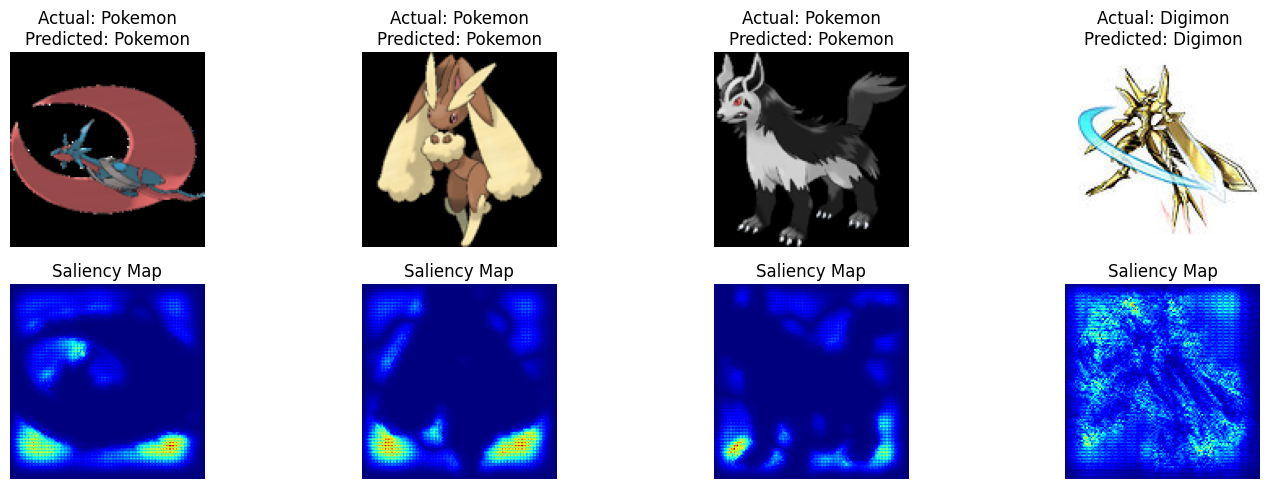

In [9]:
# Visualize saliency map
n_samples = 4
label_map = {0: 'Digimon', 1: 'Pokemon'}

random_indices = np.random.choice(test_images.shape[0], n_samples, replace=False)
sample_test_images = test_images[random_indices]
sample_test_labels = test_labels[random_indices]

sample_test_images_preprocessed = sample_test_images / 255.0
sample_test_images_tensor = tf.convert_to_tensor(sample_test_images_preprocessed, dtype=tf.float32)
true_label_indices = np.argmax(sample_test_labels, axis=1)

with tf.GradientTape() as tape:
    tape.watch(sample_test_images_tensor)
    predictions = model(sample_test_images_tensor)
    true_predictions = tf.gather(predictions, true_label_indices, axis=1, batch_dims=1)
    sample_test_labels = np.argmax(sample_test_labels, axis=1)
    predicted_labels = np.argmax(predictions, axis=1)

gradients = tape.gradient(true_predictions, sample_test_images_tensor)
print("Gradients stats:", np.min(gradients), np.max(gradients), np.mean(gradients))
saliency_maps = tf.reduce_max(tf.abs(gradients), axis=-1)

if np.all(gradients.numpy() == 0):
    raise ValueError("Gradients are zero. There might be an issue with the model or the loss computation.")

rows = 2
cols = n_samples
fig, axes = plt.subplots(rows, cols, figsize=(15, 5))
for i, (image, saliency_map) in enumerate(zip(sample_test_images_tensor, saliency_maps)):
    # Resize saliency map
    saliency_map_resized = tf.image.resize(saliency_map[..., tf.newaxis], (120, 120)).numpy().squeeze()
    axes[0, i].imshow(image)
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Actual: {label_map[sample_test_labels[i]]}\nPredicted: {label_map[predicted_labels[i]]}")
    axes[1, i].imshow(saliency_map_resized, cmap='jet')
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Saliency Map")
plt.tight_layout()
plt.show()